In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import ttest_rel
import re
import os
from matplotlib.lines import Line2D
import glob

In [90]:
full_data = ['lab_data/mct_90-120_nx_90-110/vols_dj988_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_es189_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_hw113_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_jf522_nx_mct.csv',
'lab_data/vols_jt424.csv',
'lab_data/mct_90-120_nx_90-110/vols_nb018_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_rh260_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_sr773_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_wg963_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_js502_nx_mct.csv',
'lab_data/mct_90-120_nx_90-110/vols_em982_nx_mct.csv']

In [91]:
nx_cerebellum = [0.4999612, 0.5840042, 0.7166024, 0.5177865, 0.5127563, 0.5452158, 0.606594, 0.5583543, 0.5842307, 0.5500565, 0.7435939]

In [92]:
mct_cerebellum = [0.4658982, 0.52038, 0.6343885, 0.5197383, 0.3806655, 0.5028403, 0.621303, 0.5318747, 0.685717, 0.5710577, 0.7013525]

In [93]:
# Load all data and extract NX and MCT Image mean values
all_mct_values = []
all_nx_values = []
all_labels = []

for file_idx, file_path in enumerate(full_data):
    df = pd.read_csv(file_path)
    
    # Find columns containing "nx" and "mct" with "Image mean"
    nx_col = None
    mct_col = None
    
    for col in df.columns:
        if 'Image mean' in col:
            if 'nx' in col.lower():
                nx_col = col
            elif 'mct' in col.lower():
                mct_col = col
    
    if nx_col is None or mct_col is None:
        print(f"Warning: Could not find both NX and MCT columns in {file_path}")
        continue
    
    # Get the cerebellum reference values for this file (index-correlated)
    nx_cerebellum_ref = nx_cerebellum[file_idx]
    mct_cerebellum_ref = mct_cerebellum[file_idx]
    
    # Exclude "Clear Label" rows
    df_filtered = df[df['Label Name'] != 'Clear Label'].copy()
    
    # Extract values
    for idx, row in df_filtered.iterrows():
        mct_val = row[mct_col]
        nx_val = row[nx_col]
        
        # Only include if both values are not NaN
        if pd.notna(mct_val) and pd.notna(nx_val):
            # Normalize MCT value by dividing by cerebellum reference
            mct_normalized = mct_val / mct_cerebellum_ref
            all_mct_values.append(mct_normalized)
            # Normalize NX value by dividing by cerebellum reference
            nx_normalized = nx_val / nx_cerebellum_ref
            all_nx_values.append(nx_normalized)
            all_labels.append(row['Label Name'])

# Convert to numpy arrays
mct_array = np.array(all_mct_values)
nx_array = np.array(all_nx_values)

print(f"Total data points: {len(mct_array)}")
print(f"MCT column: {mct_col} (normalized by cerebellum reference)")
print(f"NX column: {nx_col} (normalized by cerebellum reference)")

Total data points: 242
MCT column: Image mean (resliced mct_tau_pet_90_120) (normalized by cerebellum reference)
NX column: Image mean (resliced nx_tau_pet_90_110) (normalized by cerebellum reference)


Number of unique regions: 22
Regions: ['Left BA35', 'Left BA36', 'Left CA1', 'Left CA2', 'Left CA3', 'Left DG', 'Left ERC', 'Left PHC', 'Left SUB', 'Left misc', 'Left sulcus', 'Right BA35', 'Right BA36', 'Right CA1', 'Right CA2', 'Right CA3', 'Right DG', 'Right ERC', 'Right PHC', 'Right SUB', 'Right misc', 'Right sulcus']


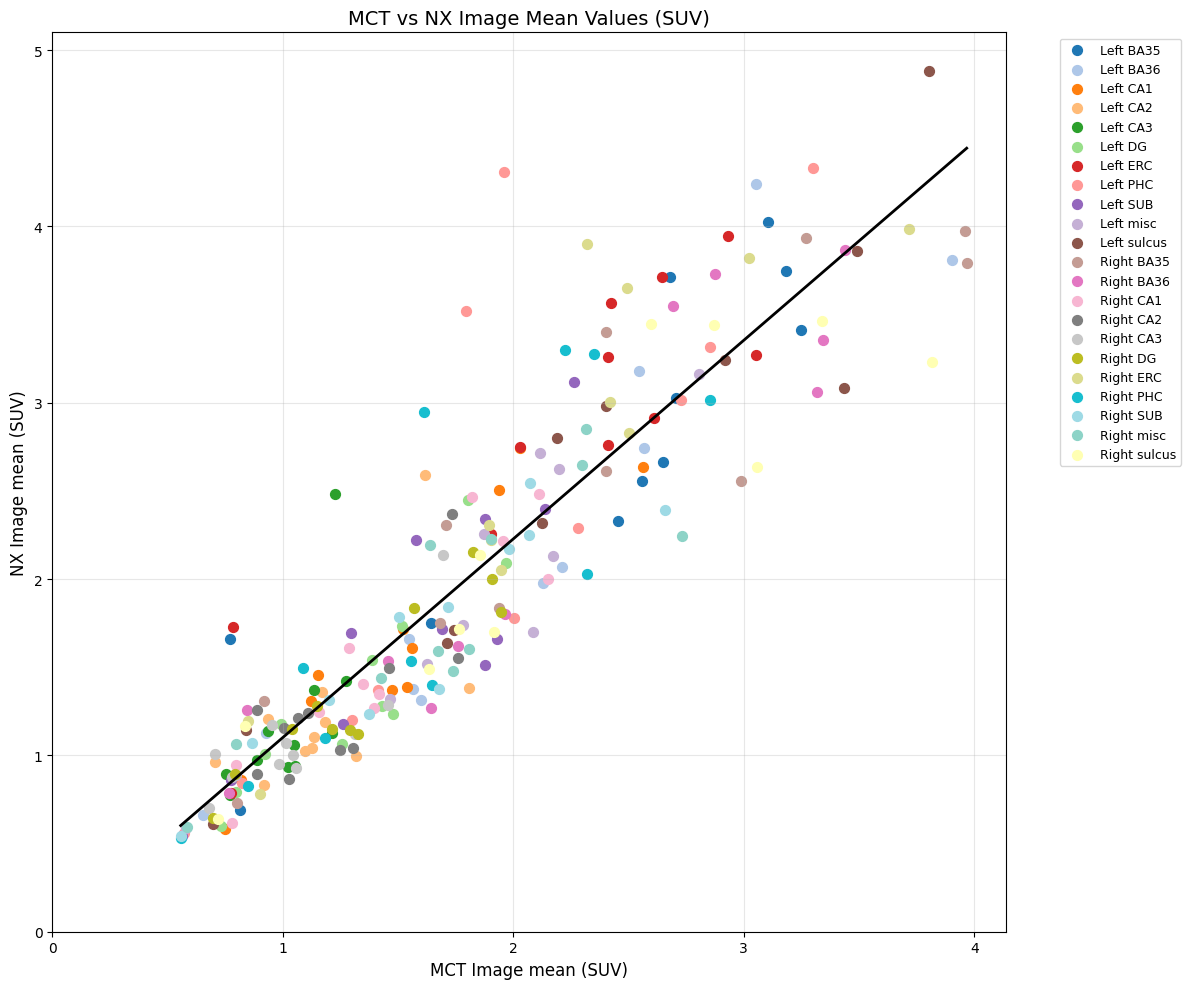


Best fit line parameters:
Slope: 1.126452
Y-intercept: -0.025919
Equation: y = 1.126452x + -0.025919


In [94]:
# Get unique regions and assign colors
unique_regions = sorted(set(all_labels))
print(f"Number of unique regions: {len(unique_regions)}")
print(f"Regions: {unique_regions}")

# Create color map for 22 regions
# Using a colormap that provides distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, 20))  # 20 colors from tab20
colors = np.vstack([colors, plt.cm.Set3(np.linspace(0, 1, 12))[:2]])  # Add 2 more from Set3
region_color_map = {region: colors[i] for i, region in enumerate(unique_regions)}

# Create scatter plot with color coding by region
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each region with its assigned color
for region in unique_regions:
    # Find indices for this region
    region_mask = np.array(all_labels) == region
    region_mct = mct_array[region_mask]
    region_nx = nx_array[region_mask]
    
    ax.scatter(region_mct, region_nx, alpha=1, s=50, 
               color=region_color_map[region], label=region)

# Fit best fit line using numpy polyfit
coefficients = np.polyfit(mct_array, nx_array, 1)
slope = coefficients[0]
y_intercept = coefficients[1]

# Create line for plotting
line_x = np.linspace(mct_array.min(), mct_array.max(), 100)
line_y = slope * line_x + y_intercept

# Plot best fit line in black, no label
ax.plot(line_x, line_y, 'k-', linewidth=2)

# Set axes to start at 0,0
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Set axis ticks to natural numbers (integers)
max_x = int(np.ceil(mct_array.max()))
max_y = int(np.ceil(nx_array.max()))
ax.set_xticks(range(0, max_x + 1))
ax.set_yticks(range(0, max_y + 1))

ax.set_xlabel('MCT Image mean (SUV)', fontsize=12)
ax.set_ylabel('NX Image mean (SUV)', fontsize=12)
ax.set_title('MCT vs NX Image Mean Values (SUV)', fontsize=14)
ax.grid(True, alpha=0.3)

# Create legend outside the plot area
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# Print slope and y-intercept
print(f"\nBest fit line parameters:")
print(f"Slope: {slope:.6f}")
print(f"Y-intercept: {y_intercept:.6f}")
print(f"Equation: y = {slope:.6f}x + {y_intercept:.6f}")

In [95]:
# Load all data and extract NX and MCT Image mean values, tracking file IDs
# Normalize both NX and MCT values by dividing by respective cerebellum references
all_mct_values = []
all_nx_values = []
all_file_ids = []

for file_idx, file_path in enumerate(full_data):
    df = pd.read_csv(file_path)
    
    # Extract file ID from path (e.g., "dj988" from "vols_dj988_nx_mct.csv")
    file_id = file_path.split('vols_')[1].split('_nx_mct')[0]
    
    # Find columns containing "nx" and "mct" with "Image mean"
    nx_col = None
    mct_col = None
    
    for col in df.columns:
        if 'Image mean' in col:
            if 'nx' in col.lower():
                nx_col = col
            elif 'mct' in col.lower():
                mct_col = col
    
    if nx_col is None or mct_col is None:
        print(f"Warning: Could not find both NX and MCT columns in {file_path}")
        continue
    
    # Get the cerebellum reference values for this file (index-correlated)
    nx_cerebellum_ref = nx_cerebellum[file_idx]
    mct_cerebellum_ref = mct_cerebellum[file_idx]
    
    # Exclude "Clear Label" rows
    df_filtered = df[df['Label Name'] != 'Clear Label'].copy()
    
    # Extract values
    for idx, row in df_filtered.iterrows():
        mct_val = row[mct_col]
        nx_val = row[nx_col]
        
        # Only include if both values are not NaN
        if pd.notna(mct_val) and pd.notna(nx_val):
            # Normalize MCT value by dividing by cerebellum reference
            mct_normalized = mct_val / mct_cerebellum_ref
            all_mct_values.append(mct_normalized)
            # Normalize NX value by dividing by cerebellum reference
            nx_normalized = nx_val / nx_cerebellum_ref
            all_nx_values.append(nx_normalized)
            all_file_ids.append(file_id)

# Convert to numpy arrays
mct_array = np.array(all_mct_values)
nx_array = np.array(all_nx_values)

# Get unique file IDs and assign colors
unique_file_ids = sorted(set(all_file_ids))
print(f"Number of unique files: {len(unique_file_ids)}")
print(f"File IDs: {unique_file_ids}")

# Create color map for 11 files
# Using a colormap that provides distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, 20))  # 20 colors from tab20
file_color_map = {file_id: colors[i] for i, file_id in enumerate(unique_file_ids)}

Number of unique files: 11
File IDs: ['dj988', 'em982', 'es189', 'hw113', 'jf522', 'js502', 'jt424.csv', 'nb018', 'rh260', 'sr773', 'wg963']


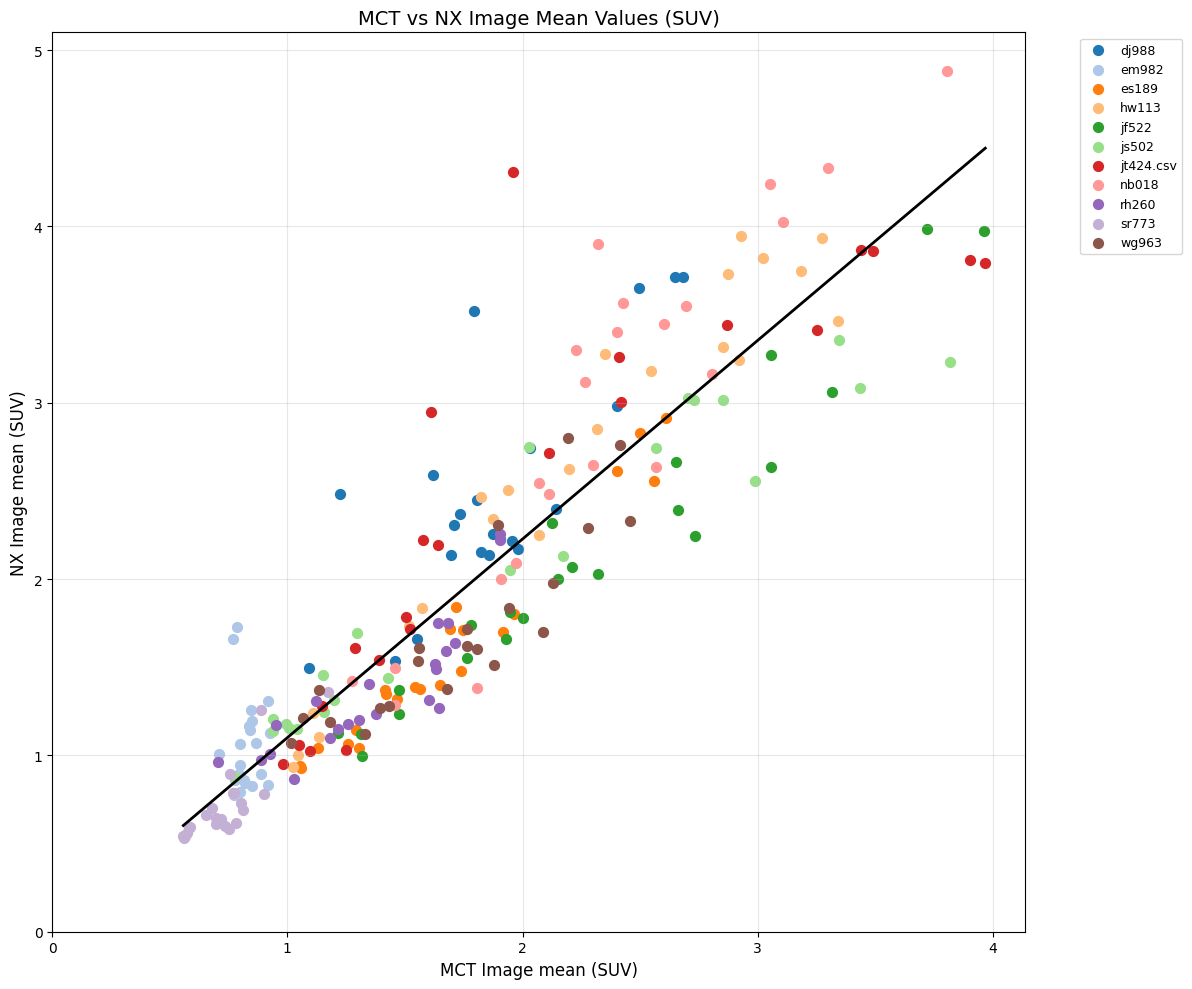


Best fit line parameters:
Slope: 1.126452
Y-intercept: -0.025919
Equation: y = 1.126452x + -0.025919


In [96]:
# Create scatter plot with color coding by file ID
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each file with its assigned color
for file_id in unique_file_ids:
    # Find indices for this file
    file_mask = np.array(all_file_ids) == file_id
    file_mct = mct_array[file_mask]
    file_nx = nx_array[file_mask]
    
    ax.scatter(file_mct, file_nx, alpha=1, s=50, 
               color=file_color_map[file_id], label=file_id)

# Fit best fit line using numpy polyfit
coefficients = np.polyfit(mct_array, nx_array, 1)
slope = coefficients[0]
y_intercept = coefficients[1]

# Create line for plotting
line_x = np.linspace(mct_array.min(), mct_array.max(), 100)
line_y = slope * line_x + y_intercept

# Plot best fit line in black, no label
ax.plot(line_x, line_y, 'k-', linewidth=2)

# Set axes to start at 0,0
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Set axis ticks to natural numbers (integers)
max_x = int(np.ceil(mct_array.max()))
max_y = int(np.ceil(nx_array.max()))
ax.set_xticks(range(0, max_x + 1))
ax.set_yticks(range(0, max_y + 1))

ax.set_xlabel('MCT Image mean (SUV)', fontsize=12)
ax.set_ylabel('NX Image mean (SUV)', fontsize=12)
ax.set_title('MCT vs NX Image Mean Values (SUV)', fontsize=14)
ax.grid(True, alpha=0.3)

# Create legend outside the plot area
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# Print slope and y-intercept
print(f"\nBest fit line parameters:")
print(f"Slope: {slope:.6f}")
print(f"Y-intercept: {y_intercept:.6f}")
print(f"Equation: y = {slope:.6f}x + {y_intercept:.6f}")

In [97]:
# Create table with ROI, difference (nx-mct), and SD
# Normalize both NX and MCT values by dividing by respective cerebellum references
roi_data = {}  # Dictionary to store data for each ROI

for file_idx, file_path in enumerate(full_data):
    df = pd.read_csv(file_path)
    
    # Find columns containing "nx" and "mct" with "Image mean" and "Image stdev"
    nx_mean_col = None
    mct_mean_col = None
    nx_stdev_col = None
    mct_stdev_col = None
    
    for col in df.columns:
        if 'Image mean' in col:
            if 'nx' in col.lower():
                nx_mean_col = col
            elif 'mct' in col.lower():
                mct_mean_col = col
        elif 'Image stdev' in col:
            if 'nx' in col.lower():
                nx_stdev_col = col
            elif 'mct' in col.lower():
                mct_stdev_col = col
    
    if nx_mean_col is None or mct_mean_col is None:
        print(f"Warning: Could not find both NX and MCT columns in {file_path}")
        continue
    
    # Get the cerebellum reference values for this file (index-correlated)
    nx_cerebellum_ref = nx_cerebellum[file_idx]
    mct_cerebellum_ref = mct_cerebellum[file_idx]
    
    # Exclude "Clear Label" rows
    df_filtered = df[df['Label Name'] != 'Clear Label'].copy()
    
    # Extract values for each ROI
    for idx, row in df_filtered.iterrows():
        roi_name = row['Label Name']
        mct_mean = row[mct_mean_col]
        nx_mean = row[nx_mean_col]
        
        # Only include if both values are not NaN
        if pd.notna(mct_mean) and pd.notna(nx_mean):
            if roi_name not in roi_data:
                roi_data[roi_name] = {'nx_values': [], 'mct_values': [], 'differences': []}
            
            # Normalize values by dividing by cerebellum references
            nx_normalized = nx_mean / nx_cerebellum_ref
            mct_normalized = mct_mean / mct_cerebellum_ref
            
            roi_data[roi_name]['nx_values'].append(nx_normalized)
            roi_data[roi_name]['mct_values'].append(mct_normalized)
            roi_data[roi_name]['differences'].append(nx_normalized - mct_normalized)

# Calculate statistics for each ROI
table_data = []
for roi_name in sorted(roi_data.keys()):
    differences = roi_data[roi_name]['differences']
    mean_difference = np.mean(differences)
    sd_difference = np.std(differences, ddof=1)  # Sample standard deviation
    
    table_data.append({
        'ROI': roi_name,
        'Difference (nx-mct)': mean_difference,
        'SD': sd_difference
    })

# Create DataFrame and display as table
results_df = pd.DataFrame(table_data)
results_df

,ROI,Difference (nx-mct),SD
0,Left BA35,0.341151,0.435683
1,Left BA36,0.131411,0.432288
2,Left CA1,0.154083,0.283370
3,Left CA2,0.060622,0.370920
4,Left CA3,0.162861,0.381593
5,Left DG,0.061169,0.251450
6,Left ERC,0.633350,0.396738
7,Left PHC,0.499980,0.846123
8,Left SUB,0.181307,0.380487
9,Left misc,0.103437,0.298073


In [98]:
# Create forest plot with ROI, difference (nx-mct), and SD
roi_data = {}  # Dictionary to store data for each ROI

for file_path in full_data:
    df = pd.read_csv(file_path)
    
    # Find columns containing "nx" and "mct" with "Image mean"
    nx_mean_col = None
    mct_mean_col = None
    
    for col in df.columns:
        if 'Image mean' in col:
            if 'nx' in col.lower():
                nx_mean_col = col
            elif 'mct' in col.lower():
                mct_mean_col = col
    
    if nx_mean_col is None or mct_mean_col is None:
        continue
    
    # Exclude "Clear Label" rows
    df_filtered = df[df['Label Name'] != 'Clear Label'].copy()
    
    # Extract values for each ROI
    for idx, row in df_filtered.iterrows():
        roi_name = row['Label Name']
        mct_mean = row[mct_mean_col]
        nx_mean = row[nx_mean_col]
        
        # Only include if both values are not NaN
        if pd.notna(mct_mean) and pd.notna(nx_mean):
            if roi_name not in roi_data:
                roi_data[roi_name] = {'differences': []}
            
            roi_data[roi_name]['differences'].append(nx_mean - mct_mean)

# Calculate statistics for each ROI
forest_data = []
for roi_name in sorted(roi_data.keys()):
    differences = roi_data[roi_name]['differences']
    mean_difference = np.mean(differences)
    sd_difference = np.std(differences, ddof=1)  # Sample standard deviation
    
    forest_data.append({
        'ROI': roi_name,
        'Difference': mean_difference,
        'SD': sd_difference
    })

In [99]:
# Create forest plot with ROI, difference (nx-mct), and SD
# Normalize both NX and MCT values by dividing by respective cerebellum references
roi_data = {}  # Dictionary to store data for each ROI

for file_idx, file_path in enumerate(full_data):
    df = pd.read_csv(file_path)
    
    # Find columns containing "nx" and "mct" with "Image mean"
    nx_mean_col = None
    mct_mean_col = None
    
    for col in df.columns:
        if 'Image mean' in col:
            if 'nx' in col.lower():
                nx_mean_col = col
            elif 'mct' in col.lower():
                mct_mean_col = col
    
    if nx_mean_col is None or mct_mean_col is None:
        continue
    
    # Get the cerebellum reference values for this file (index-correlated)
    nx_cerebellum_ref = nx_cerebellum[file_idx]
    mct_cerebellum_ref = mct_cerebellum[file_idx]
    
    # Exclude "Clear Label" rows
    df_filtered = df[df['Label Name'] != 'Clear Label'].copy()
    
    # Extract values for each ROI
    for idx, row in df_filtered.iterrows():
        roi_name = row['Label Name']
        mct_mean = row[mct_mean_col]
        nx_mean = row[nx_mean_col]
        
        # Only include if both values are not NaN
        if pd.notna(mct_mean) and pd.notna(nx_mean):
            if roi_name not in roi_data:
                roi_data[roi_name] = {'differences': []}
            
            # Normalize values by dividing by cerebellum references
            nx_normalized = nx_mean / nx_cerebellum_ref
            mct_normalized = mct_mean / mct_cerebellum_ref
            
            roi_data[roi_name]['differences'].append(nx_normalized - mct_normalized)

# Calculate statistics for each ROI
forest_data = []
for roi_name in sorted(roi_data.keys()):
    differences = roi_data[roi_name]['differences']
    mean_difference = np.mean(differences)
    sd_difference = np.std(differences, ddof=1)  # Sample standard deviation
    
    forest_data.append({
        'ROI': roi_name,
        'Difference': mean_difference,
        'SD': sd_difference
    })

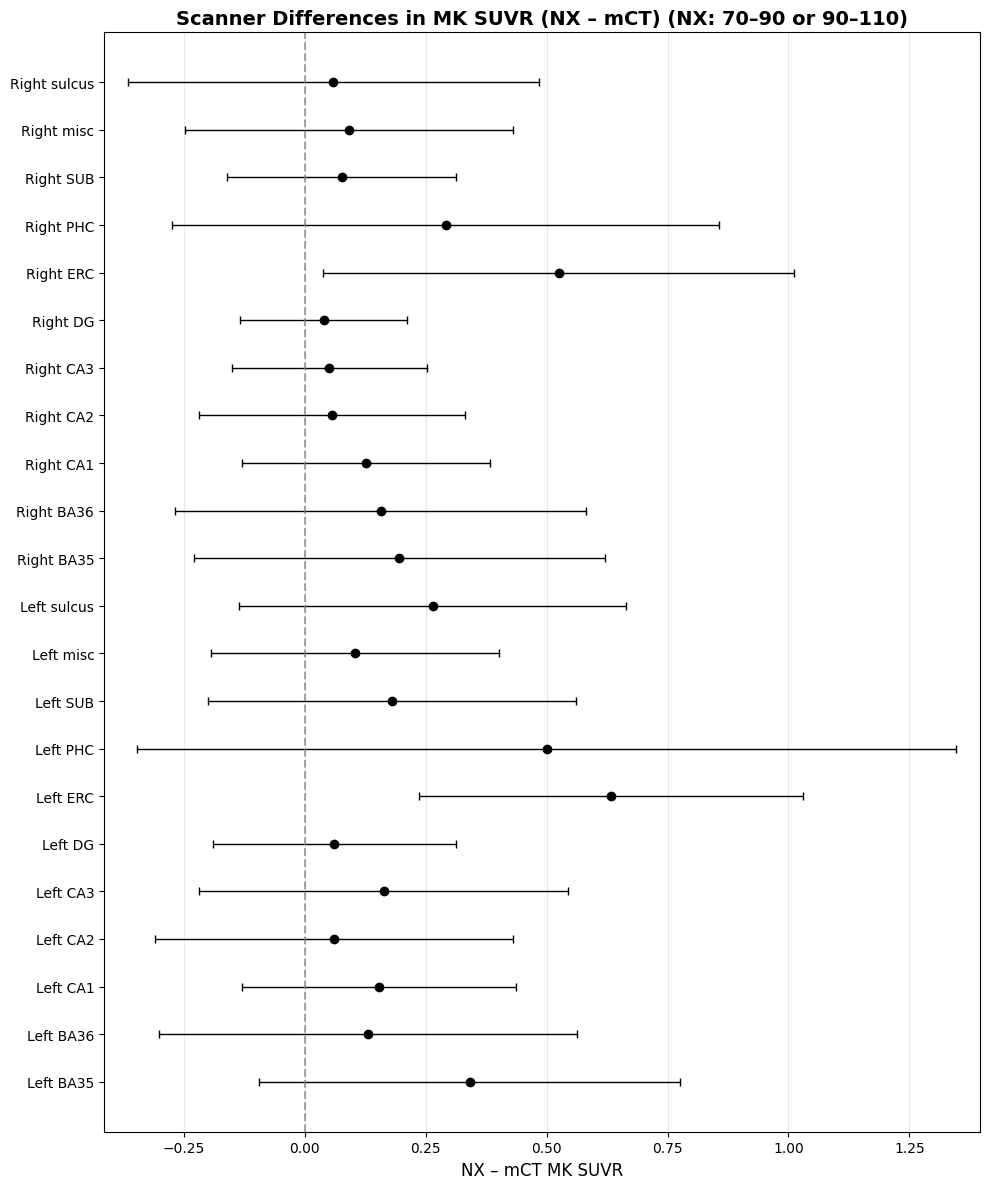

In [100]:
# Create forest plot
fig, ax = plt.subplots(figsize=(10, 12))

# Reverse order so first ROI is at top
forest_data_reversed = list(reversed(forest_data))
y_positions = np.arange(len(forest_data_reversed))

# Extract values
roi_names = [item['ROI'] for item in forest_data_reversed]
differences = [item['Difference'] for item in forest_data_reversed]
sds = [item['SD'] for item in forest_data_reversed]

# Plot error bars (horizontal)
ax.errorbar(differences, y_positions, xerr=sds, fmt='o', 
            color='black', capsize=3, capthick=1, elinewidth=1, 
            markersize=6, markeredgecolor='black', markerfacecolor='black')

# Add vertical reference line at x=0
ax.axvline(x=0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)

# Set y-axis labels
ax.set_yticks(y_positions)
ax.set_yticklabels(roi_names, fontsize=10)

# Set x-axis label
ax.set_xlabel('NX – mCT MK SUVR', fontsize=12)

# Set title
ax.set_title('Scanner Differences in MK SUVR (NX – mCT) (NX: 70–90 or 90–110)', 
             fontsize=14, fontweight='bold')

# Adjust x-axis limits to show all error bars
x_min = min([d - s for d, s in zip(differences, sds)])
x_max = max([d + s for d, s in zip(differences, sds)])
ax.set_xlim(x_min - 0.05, x_max + 0.05)

# Invert y-axis so first ROI is at top
ax.invert_yaxis()

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [106]:
# Create percentage Bland-Altman plot
# Load normalized data for Bland-Altman analysis
from scipy import stats

all_mct_suvr = []
all_nx_suvr = []
all_labels_ba = []
all_file_ids_ba = []

for file_idx, file_path in enumerate(full_data):
    df = pd.read_csv(file_path)
    
    # Extract file ID from path (e.g., "dj988" from "vols_dj988_nx_mct.csv")
    if '_nx_mct' in file_path:
        file_id = file_path.split('vols_')[1].split('_nx_mct')[0]
    else:
        # Handle special case like "vols_jt424.csv"
        file_id = file_path.split('vols_')[1].split('.csv')[0]
    
    # Find columns containing "nx" and "mct" with "Image mean"
    nx_col = None
    mct_col = None
    
    for col in df.columns:
        if 'Image mean' in col:
            if 'nx' in col.lower():
                nx_col = col
            elif 'mct' in col.lower():
                mct_col = col
    
    if nx_col is None or mct_col is None:
        continue
    
    # Get the cerebellum reference values for this file (index-correlated)
    nx_cerebellum_ref = nx_cerebellum[file_idx]
    mct_cerebellum_ref = mct_cerebellum[file_idx]
    
    # Exclude "Clear Label" rows
    df_filtered = df[df['Label Name'] != 'Clear Label'].copy()
    
    # Extract values
    for idx, row in df_filtered.iterrows():
        mct_val = row[mct_col]
        nx_val = row[nx_col]
        
        # Only include if both values are not NaN
        if pd.notna(mct_val) and pd.notna(nx_val):
            # Normalize values by dividing by cerebellum references
            mct_suvr = mct_val / mct_cerebellum_ref
            nx_suvr = nx_val / nx_cerebellum_ref
            
            all_mct_suvr.append(mct_suvr)
            all_nx_suvr.append(nx_suvr)
            all_labels_ba.append(row['Label Name'])
            all_file_ids_ba.append(file_id)

# Convert to numpy arrays
mct_suvr_array = np.array(all_mct_suvr)
nx_suvr_array = np.array(all_nx_suvr)

# Calculate mean SUVR (x-axis)
mean_suvr = (nx_suvr_array + mct_suvr_array) / 2

# Calculate percentage difference (y-axis): ((nx - mct) / mean) * 100
percent_diff = ((nx_suvr_array - mct_suvr_array) / mean_suvr) * 100

# Create color map for regions
unique_regions = sorted(set(all_labels_ba))
colors_ba = plt.cm.tab20(np.linspace(0, 1, 20))
colors_ba = np.vstack([colors_ba, plt.cm.Set3(np.linspace(0, 1, 12))[:2]])
region_color_map_ba = {region: colors_ba[i] for i, region in enumerate(unique_regions)}

# Create color map for subjects
unique_subjects = sorted(set(all_file_ids_ba))
colors_subjects = plt.cm.tab20(np.linspace(0, 1, 20))
subject_color_map_ba = {subject: colors_subjects[i] for i, subject in enumerate(unique_subjects)}

# Fit linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(mean_suvr, percent_diff)

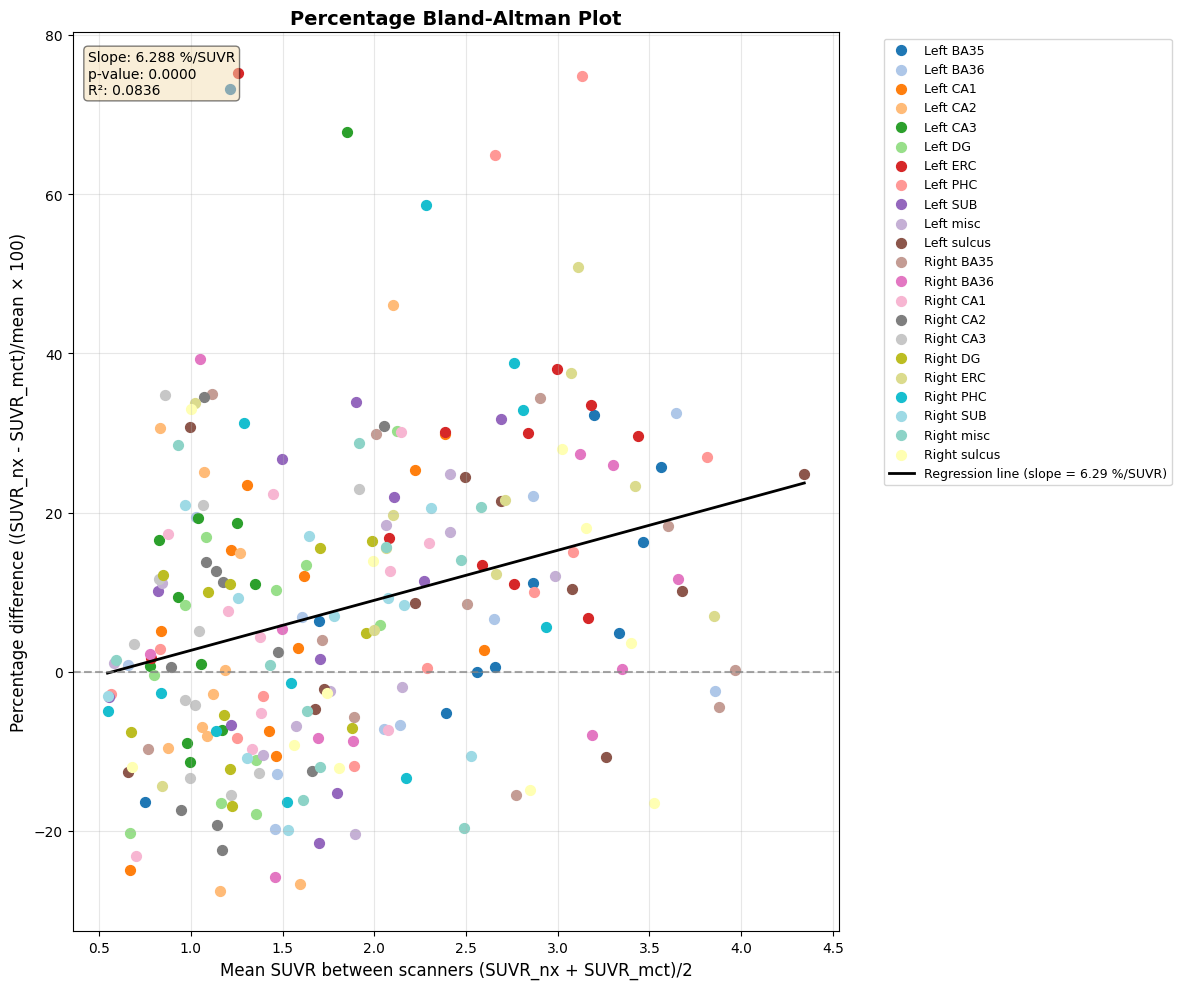

Linear regression results:
Slope: 6.288 %/SUVR
Intercept: -3.610 %
R-squared: 0.0836
p-value: 0.0000
Standard error: 1.3434
The slope is significantly different from zero (p < 0.05)


In [107]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot points color-coded by region
for region in unique_regions:
    region_mask = np.array(all_labels_ba) == region
    ax.scatter(mean_suvr[region_mask], percent_diff[region_mask], 
               alpha=1, s=50, color=region_color_map_ba[region], label=region)

# Plot regression line
line_x = np.linspace(mean_suvr.min(), mean_suvr.max(), 100)
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, 'k-', linewidth=2, label=f'Regression line (slope = {slope:.2f} %/SUVR)')

# Add horizontal line at y=0
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)

# Labels and title
ax.set_xlabel('Mean SUVR between scanners (SUVR_nx + SUVR_mct)/2', fontsize=12)
ax.set_ylabel('Percentage difference ((SUVR_nx - SUVR_mct)/mean × 100)', fontsize=12)
ax.set_title('Percentage Bland-Altman Plot', fontsize=14, fontweight='bold')

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Add grid
ax.grid(True, alpha=0.3)

# Add text box with statistics
textstr = f'Slope: {slope:.3f} %/SUVR\np-value: {p_value:.4f}\nR²: {r_value**2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Linear regression results:")
print(f"Slope: {slope:.3f} %/SUVR")
print(f"Intercept: {intercept:.3f} %")
print(f"R-squared: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Standard error: {std_err:.4f}")
if p_value < 0.05:
    print(f"The slope is significantly different from zero (p < 0.05)")
else:
    print(f"The slope is NOT significantly different from zero (p >= 0.05)")

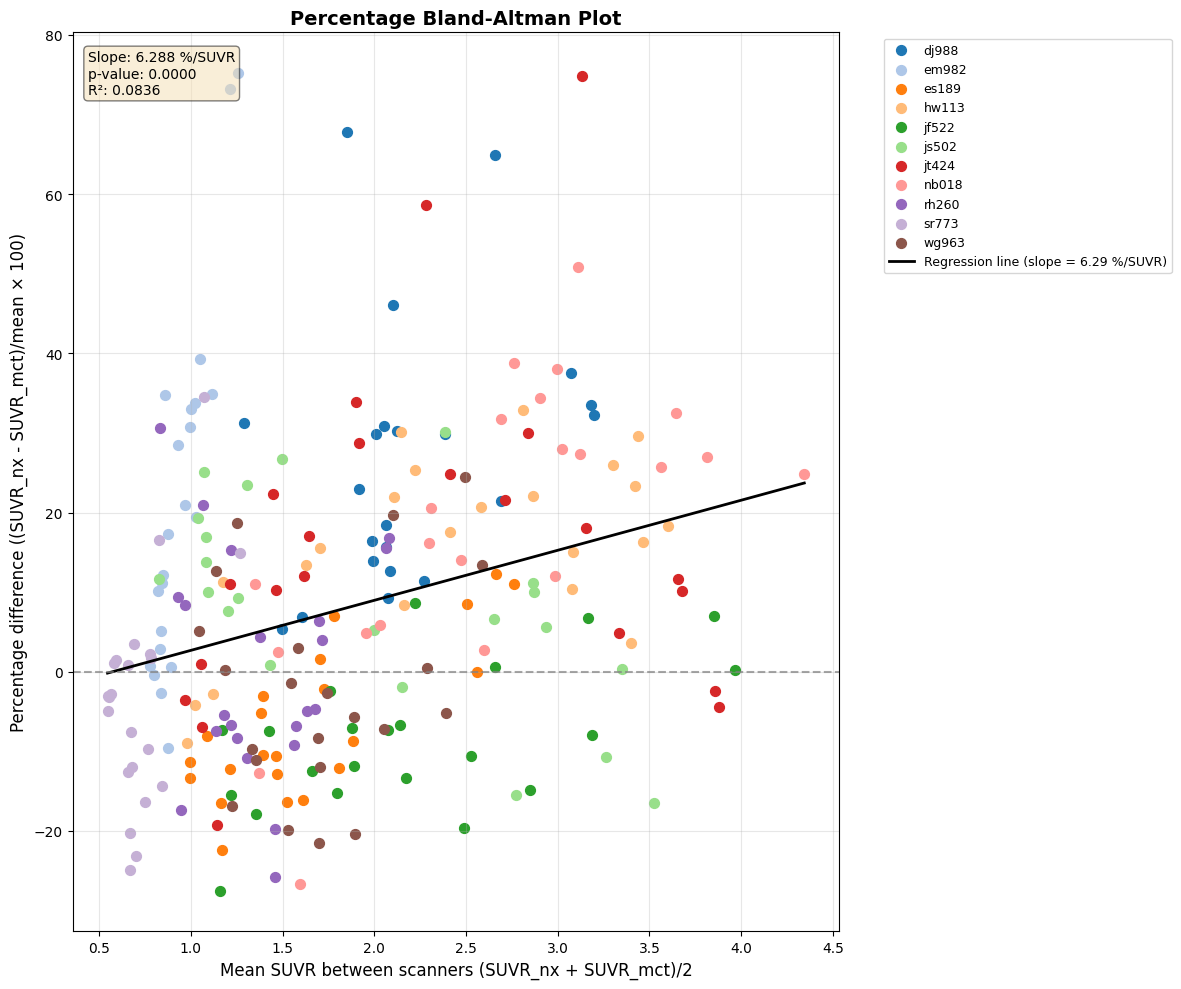

Linear regression results:
Slope: 6.288 %/SUVR
Intercept: -3.610 %
R-squared: 0.0836
p-value: 0.0000
Standard error: 1.3434
The slope is significantly different from zero (p < 0.05)


In [108]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot points color-coded by subject
for subject in unique_subjects:
    subject_mask = np.array(all_file_ids_ba) == subject
    ax.scatter(mean_suvr[subject_mask], percent_diff[subject_mask], 
               alpha=1, s=50, color=subject_color_map_ba[subject], label=subject)

# Plot regression line
line_x = np.linspace(mean_suvr.min(), mean_suvr.max(), 100)
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, 'k-', linewidth=2, label=f'Regression line (slope = {slope:.2f} %/SUVR)')

# Add horizontal line at y=0
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)

# Labels and title
ax.set_xlabel('Mean SUVR between scanners (SUVR_nx + SUVR_mct)/2', fontsize=12)
ax.set_ylabel('Percentage difference ((SUVR_nx - SUVR_mct)/mean × 100)', fontsize=12)
ax.set_title('Percentage Bland-Altman Plot', fontsize=14, fontweight='bold')

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Add grid
ax.grid(True, alpha=0.3)

# Add text box with statistics
textstr = f'Slope: {slope:.3f} %/SUVR\np-value: {p_value:.4f}\nR²: {r_value**2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Linear regression results:")
print(f"Slope: {slope:.3f} %/SUVR")
print(f"Intercept: {intercept:.3f} %")
print(f"R-squared: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Standard error: {std_err:.4f}")
if p_value < 0.05:
    print(f"The slope is significantly different from zero (p < 0.05)")
else:
    print(f"The slope is NOT significantly different from zero (p >= 0.05)")

In [104]:
# Create CSV files in "zip" folder with selected columns
import os

# Create "zip" folder if it doesn't exist
zip_folder = "lab_data/zip"

# Process each file in full_data
for file_path in full_data:
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Extract file ID from path for output filename (e.g., "dj988" from "vols_dj988_nx_mct.csv")
    file_id = file_path.split('vols_')[1].split('_nx_mct')[0]
    
    # Find columns containing resliced nx and mct data
    nx_mean_col = None
    nx_stdev_col = None
    mct_mean_col = None
    mct_stdev_col = None
    
    for col in df.columns:
        if 'Image mean' in col and 'resliced' in col.lower():
            if 'nx' in col.lower():
                nx_mean_col = col
            elif 'mct' in col.lower():
                mct_mean_col = col
        elif 'Image stdev' in col and 'resliced' in col.lower():
            if 'nx' in col.lower():
                nx_stdev_col = col
            elif 'mct' in col.lower():
                mct_stdev_col = col
    
    # Check if all required columns were found
    if None in [nx_mean_col, nx_stdev_col, mct_mean_col, mct_stdev_col]:
        print(f"Warning: Could not find all required columns in {file_path}")
        print(f"  Found: nx_mean={nx_mean_col}, nx_stdev={nx_stdev_col}, mct_mean={mct_mean_col}, mct_stdev={mct_stdev_col}")
        continue
    
    # Create new dataframe with selected columns
    output_df = pd.DataFrame({
        'Label Name': df['Label Name'],
        'Number of Voxels': df['Number Of Voxels'],  # Note: keeping original capitalization
        'Volume': df['Volume (mm^3)'],  # Simplified name
        'Image Mean nx': df[nx_mean_col],
        'Image stdev nx': df[nx_stdev_col],
        'Image Mean mct': df[mct_mean_col],
        'Image stdev mct': df[mct_stdev_col]
    })
    
    # Create output filename
    output_filename = os.path.join(zip_folder, f"{file_id}_processed.csv")
    
    # Save to CSV
    output_df.to_csv(output_filename, index=False)
    print(f"Created: {output_filename}")

print(f"\nAll CSV files created in '{zip_folder}' folder.")

Created: lab_data/zip/dj988_processed.csv
Created: lab_data/zip/es189_processed.csv
Created: lab_data/zip/hw113_processed.csv
Created: lab_data/zip/jf522_processed.csv
Created: lab_data/zip/jt424.csv_processed.csv
Created: lab_data/zip/nb018_processed.csv
Created: lab_data/zip/rh260_processed.csv
Created: lab_data/zip/sr773_processed.csv
Created: lab_data/zip/wg963_processed.csv
Created: lab_data/zip/js502_processed.csv
Created: lab_data/zip/em982_processed.csv

All CSV files created in 'lab_data/zip' folder.
